## Learning objectives
- Walk through creating a calibrated explainer for binary classification and visualizing factual explanations;
- Learn how to extract and interpret alternative explanations and uncertainty plots;
- Try conjunctive rules to explore interactions and save plots for reporting.

## Time to run
~2–10 min depending on dataset and environment (use smaller dataset variants for a faster run).


# Calibrated Explanations for Binary Classification
## Demonstrated on the diabetes data set

Author: Tuwe Löfström (tuwe.lofstrom@ju.se)  
Copyright 2023 Tuwe Löfström  
License: BSD 3 clause
Sources:
1. [Pima Indians Diabetes Database [kaggle]](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)
2. ["Calibrated Explanations: with Uncertainty Information and Counterfactuals"](https://arxiv.org/abs/2305.02305) by [Helena Löfström](https://github.com/Moffran), [Tuwe Löfström](https://github.com/tuvelofstrom), Ulf Johansson, and Cecilia Sönströd.

### 1. Import packages, data and train an underlying model
#### 1.1 Import packages

In the examples below, we will be using `NumPy`, `pandas`, and `sklearn`.  `WrapCalibratedExplainer` and `VennAbers` are imported from `calibrated_explanations`. `VennAbers` is used to demonstrate how it can be used to calibrate an underlying model. 

**Calibrated explanations, from binary and multiclass classification to probabilistic and interval regression.** Run this notebook after the README and docs quickstarts to see the same calibrated journey in action.

- [Classification quickstart](../docs/get-started/quickstart_classification.md) · [Binary notebook](demo_binary_classification.ipynb)
- [Regression quickstart](../docs/get-started/quickstart_regression.md) · [Probabilistic notebook](demo_probabilistic_regression.ipynb)

> 🎓 **Backed by research:** consult [docs/citing.md](../docs/citing.md) for the publications covering binary & multiclass classification plus probabilistic and interval regression.
> 
> 🔺 **Triangular alternatives:** when you call `explore_alternatives`, pair the results with `plot(style="triangular")` to interpret uncertainty shifts. Fast explanations ship as an optional external plugin via `pip install "calibrated-explanations[external-plugins]"`.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=UserWarning)


from calibrated_explanations import WrapCalibratedExplainer, __version__

print(f"calibrated_explanations {__version__}")

calibrated_explanations v0.11.2


#### 1.2 Import data and train a model
Let us import the Califronia Housing data set (see sources at the top).

In [3]:
dataset = "diabetes_full"
delimiter = ","
model = "RF"
print(dataset)

filename = "../../data/" + dataset + ".csv"
df = pd.read_csv(filename, delimiter=delimiter)
target = "Y"
X, y = df.drop(target, axis=1), df[target]
df.head()

diabetes_full


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Y
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Let us split the data set into a training and a test set, and further split the training set into a proper training set and a calibration set. 

In [4]:
num_to_test = 2  # number of instances to test, one from each class

no_of_classes = len(np.unique(y))
no_of_features = X.shape[1]
no_of_instances = X.shape[0]

# find categorical features
categorical_features = [i for i in range(no_of_features) if len(np.unique(X.iloc[:, i])) < 10]

# select test instances from each class and split into train, cal and test
idx = np.argsort(y.values).astype(int)
X, y = X.values[idx, :], y.values[idx]
test_index = np.array(
    [
        *range(int(num_to_test / 2)),
        *range(no_of_instances - 1, no_of_instances - int(num_to_test / 2) - 1, -1),
    ]
)
train_index = np.setdiff1d(np.array(range(no_of_instances)), test_index)
x_train, x_test = X[train_index, :], X[test_index, :]
y_train, y_test = y[train_index], y[test_index]
X_prop_train, x_cal, y_prop_train, y_cal = train_test_split(
    x_train, y_train, test_size=0.33, random_state=42, stratify=y_train
)

print(y_test)
print(categorical_features)

[0 1]
[]


Let us fit a random forest to the proper training set. We also set a random seed to be able to rerun the notebook and get the same results.

In [5]:
model = RandomForestClassifier()

model.fit(X_prop_train, y_prop_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Create the `WrapCalibratedExplainer` by feeding the model and the calibration set as a minimum (mode is 'classification' by default). 

In [6]:
ce = WrapCalibratedExplainer(model)
ce.calibrate(x_cal, y_cal, feature_names=df.columns, categorical_features=categorical_features, class_labels={0: "Non-diabetic", 1: "Diabetic"})
display(ce)

C:\Users\loftuw\AppData\Local\Python\pythoncore-3.14-64\Lib\importlib\__init__.py:88: UserWarning: Cache backend fallback: using minimal in-package LRU/TTL implementation due to missing 'cachetools'
  return _bootstrap._gcd_import(name[level:], package, level)


WrapCalibratedExplainer(learner=RandomForestClassifier(), fitted=True, calibrated=True, 
		explainer=CalibratedExplainer(mode=classification, learner=RandomForestClassifier()))

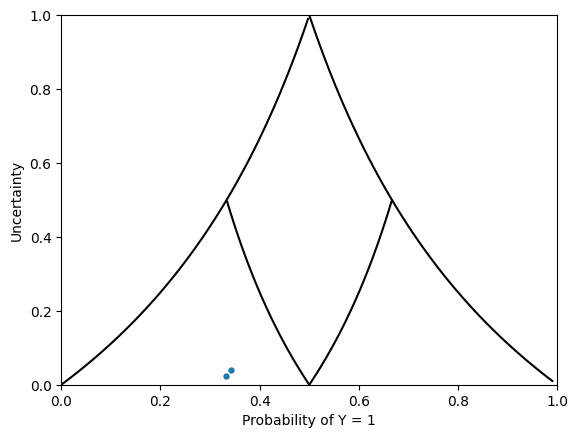

In [7]:
ce.plot(x_test)

#### Regular and uncertainty explanations
When using regular or uncertainty plots, the recommended (and for classification default) `Discretizer` is the `BinaryEntropyDiscretizer`. As no discretizer was assigned at initialization, it is already assigned `BinaryEntropyDiscretizer`. 

Once the explanations are extracted, we can visualize them using regular or uncertainty plots. The regular plot include an uncertainty interval for each class and the weights of the most influential features. The weights (positive or negative) always indicate the impact on the blue class. However, the colors are used to indicate which class is positively affected. Negative (red) weights are reducing the probability of the blue class and increasing the probability of the red class. 

Regular plots are shown by calling the function `plot`, with `filter_top` indicating the number of features to include, in order of importance. To save the plots to disk, `save_ext` can take one or several of the following extensions `['pdf','svg','png']` creating a plot for each instance and file format. 

C:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


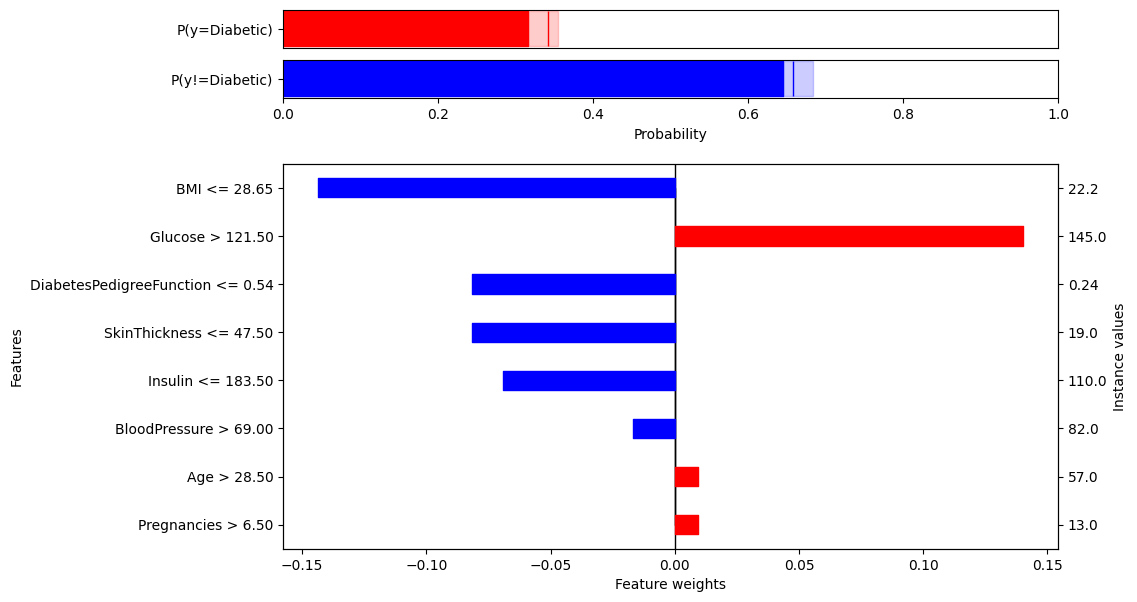

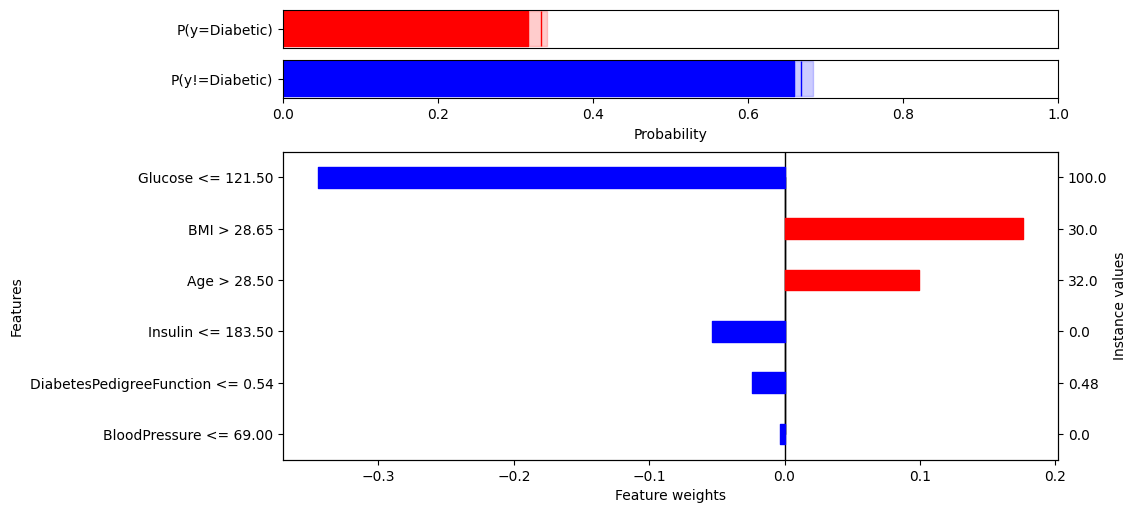

In [8]:
factual_explanation = ce.explain_factual(x_test)
factual_explanation.plot()

Uncertainty plots are similar to regular plots but also provide an uncertainty estimate for the impact of each feature. Here, the shaded area is the range of possible changes that each feature can result in.

To get uncertainty plots, simply call `plot` with the parameter `uncertainty=True`.

C:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


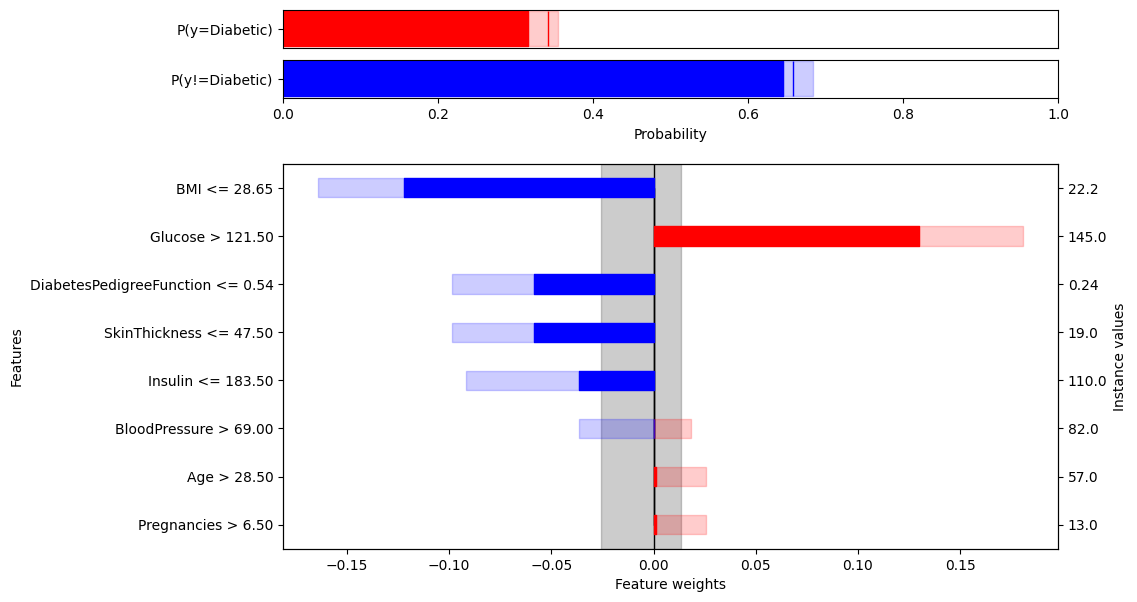

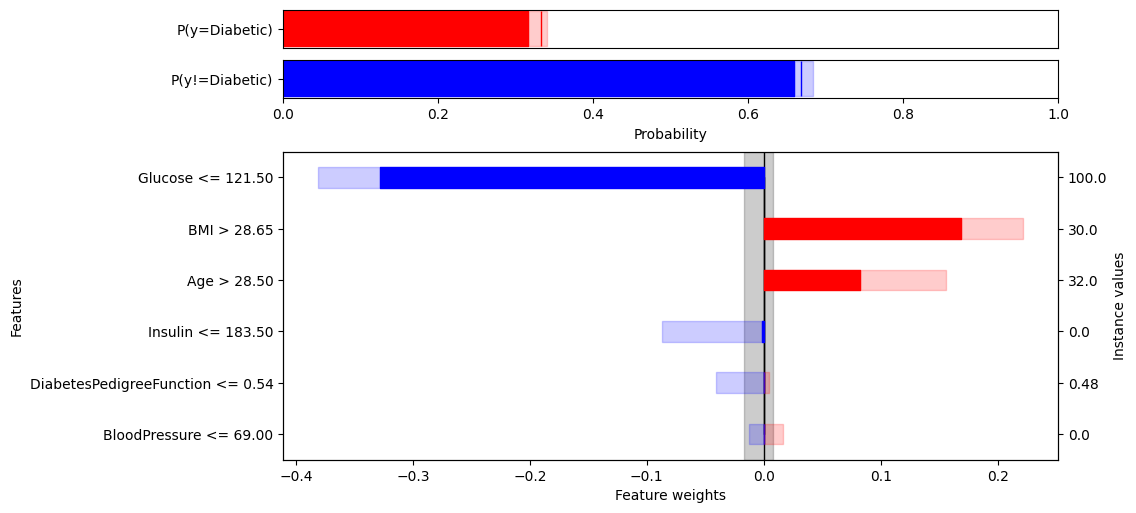

In [9]:
factual_explanation.plot(uncertainty=True)

#### Conjunctive rules
In the examples above, each explanation only contained atomic rules, including a single feature. It is also possible to combine rules and see the combined impact of more than one feature.

C:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


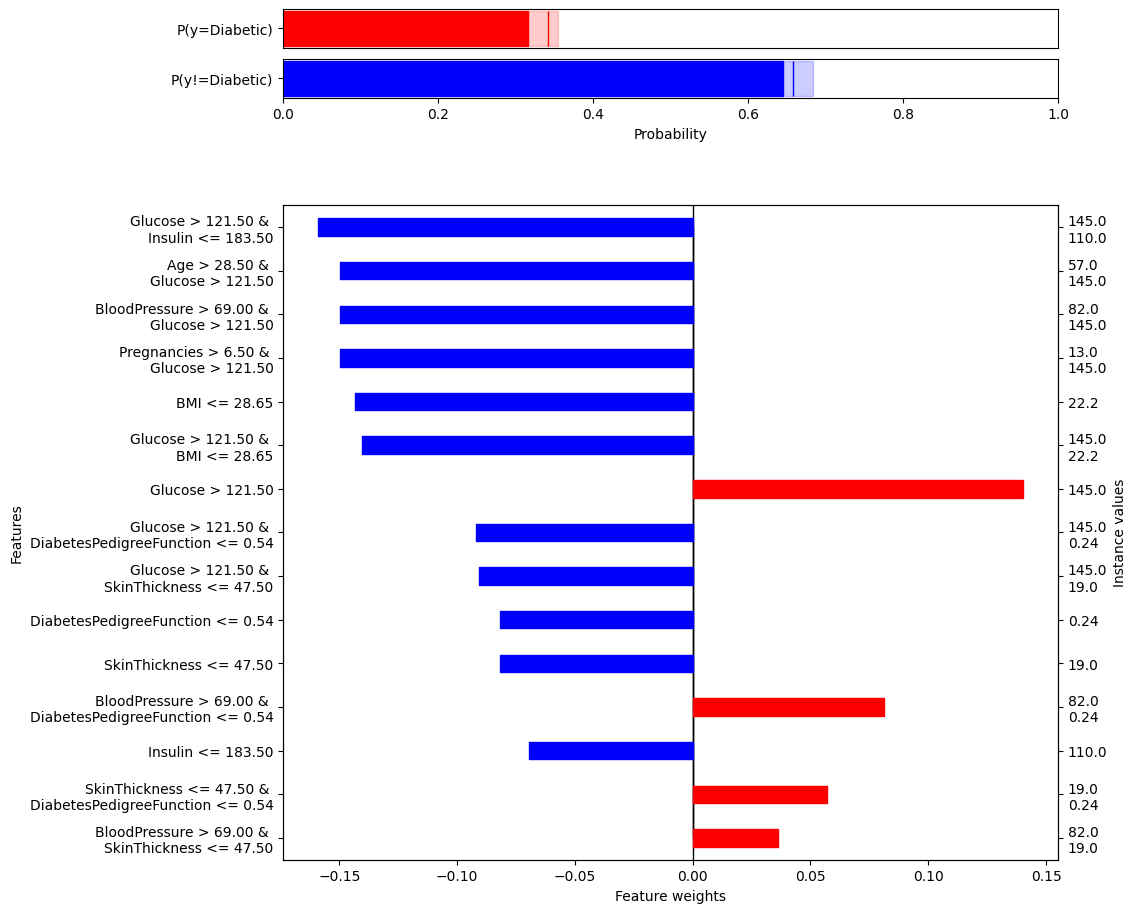

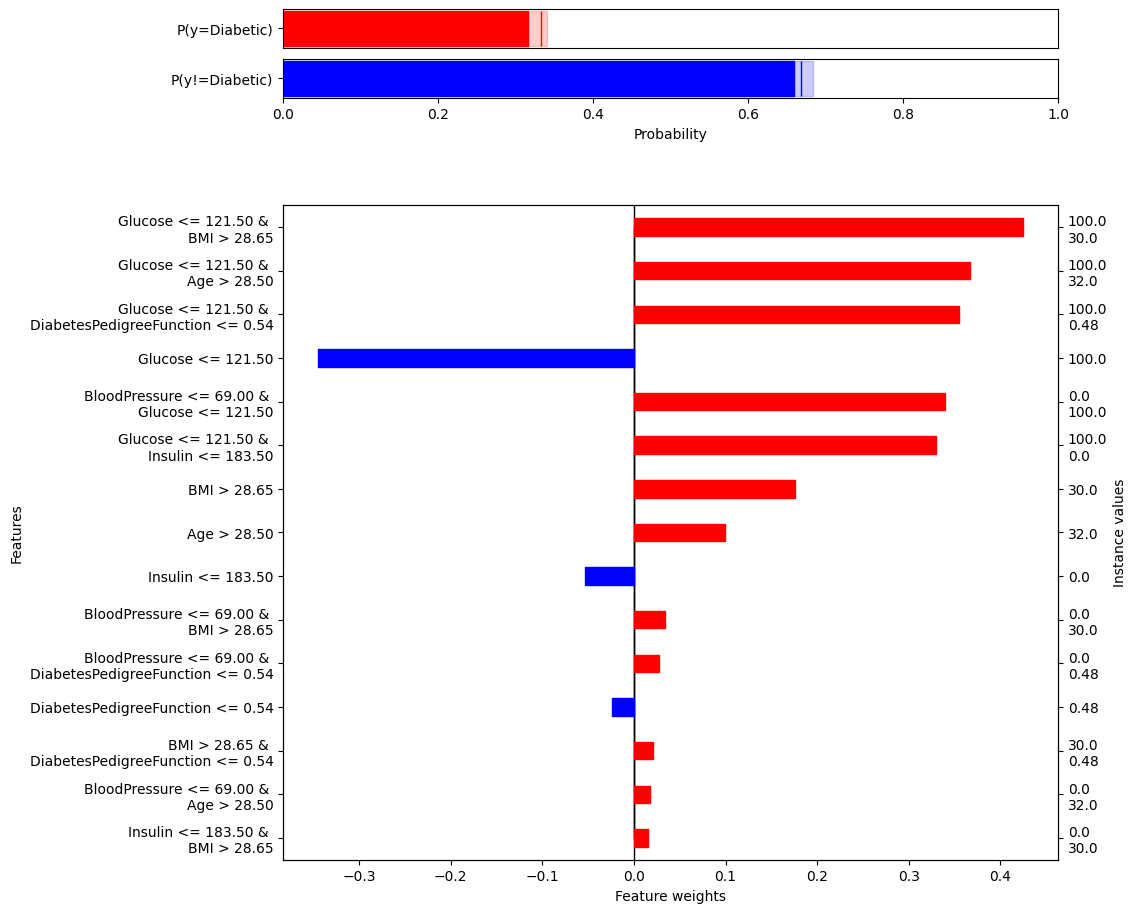

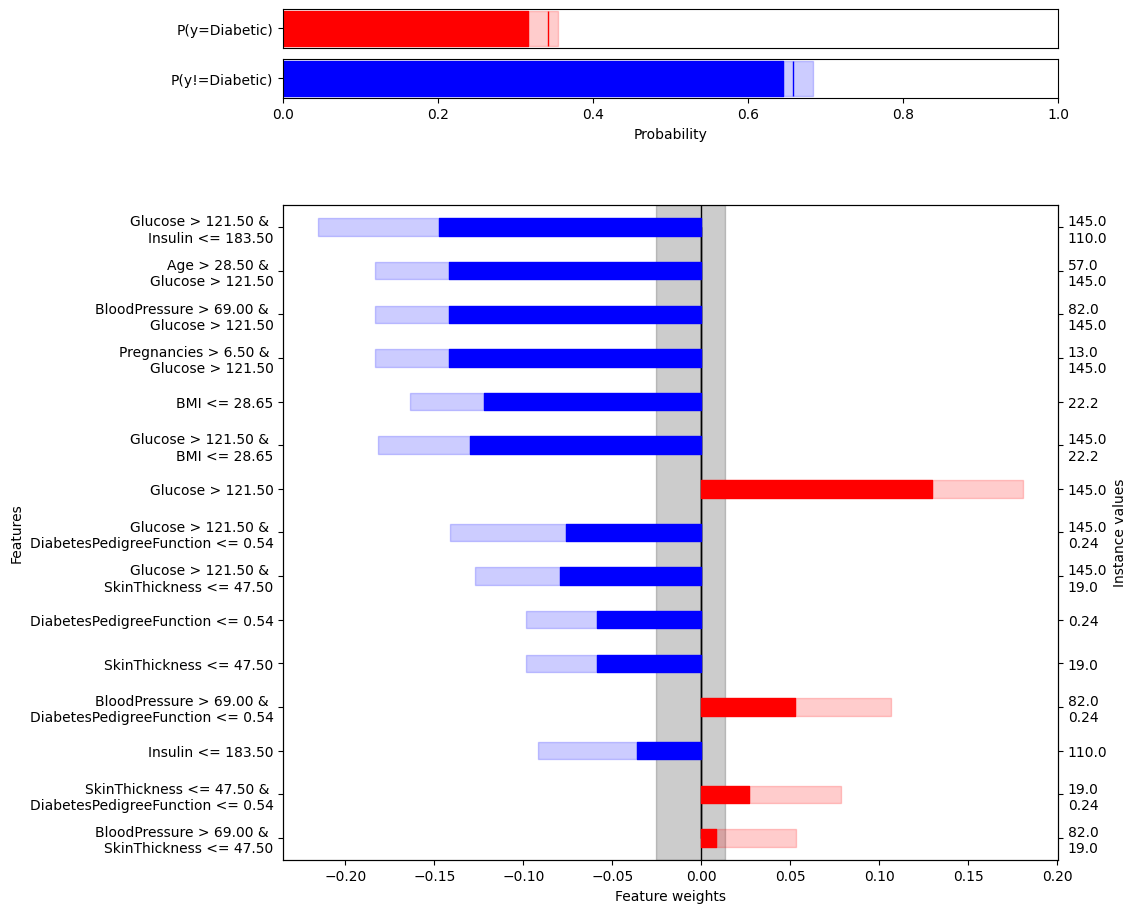

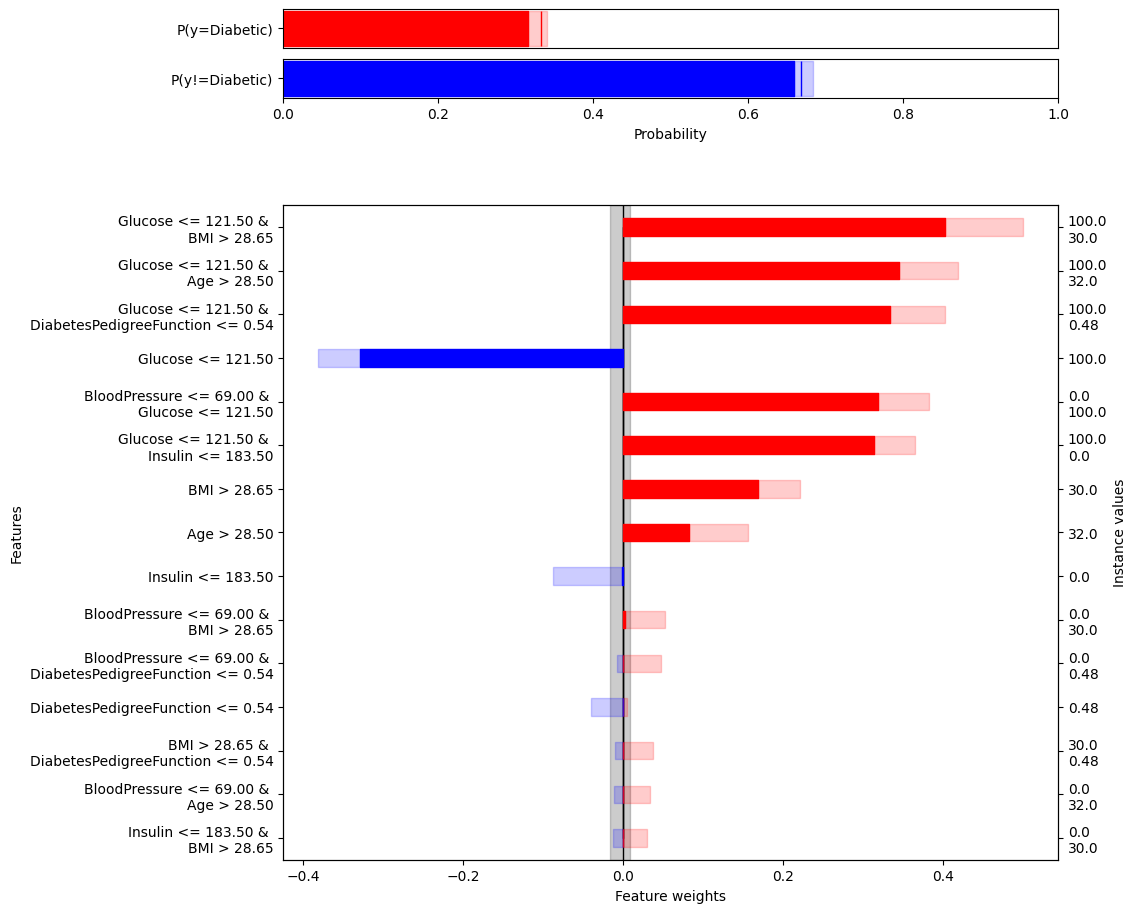

In [10]:
factual_explanation.add_conjunctions()
factual_explanation.plot(filter_top=15)
factual_explanation.plot(uncertainty=True, filter_top=15)

#### Alternative explanations
When using alternative explanations, the recommended `Discretizer` is the `EntropyDiscretizer`. The discretizer can be changed into `EntropyDiscretizer` by invoking `set_discretizer('entropy')`. Alternative explanations are extracted in the same way as regular and uncertainty explanations. The `EntropyDiscretizer` allows for more varied and precise alternative rules. The function `explore_alternatives` will automatically assign recommended discretizer.

Once the explanations are extracted, we can visualize them using `plot` function. The alternative plot visualize the probability interval for the positive class (`Diabetic` in this example). The alternative rules indicate what the interval would have changed into had the feature values changed according to the rule condition.

C:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


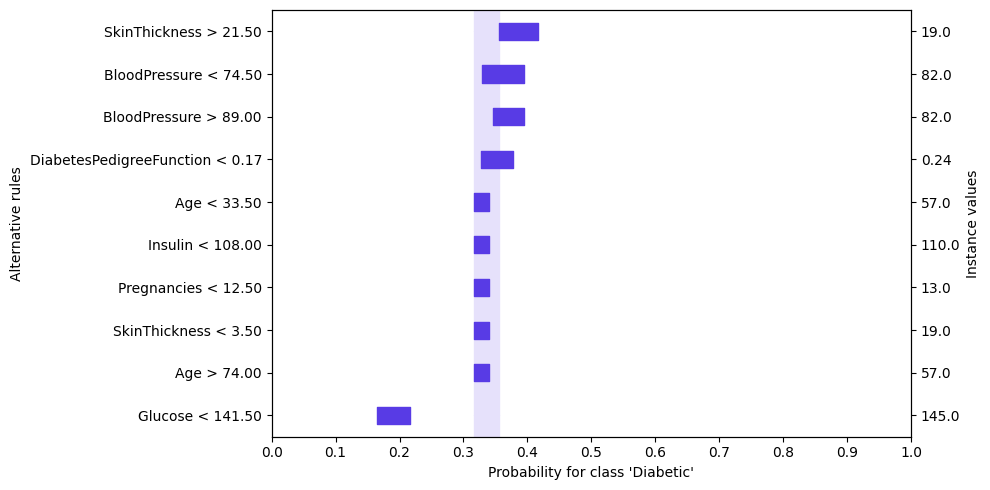

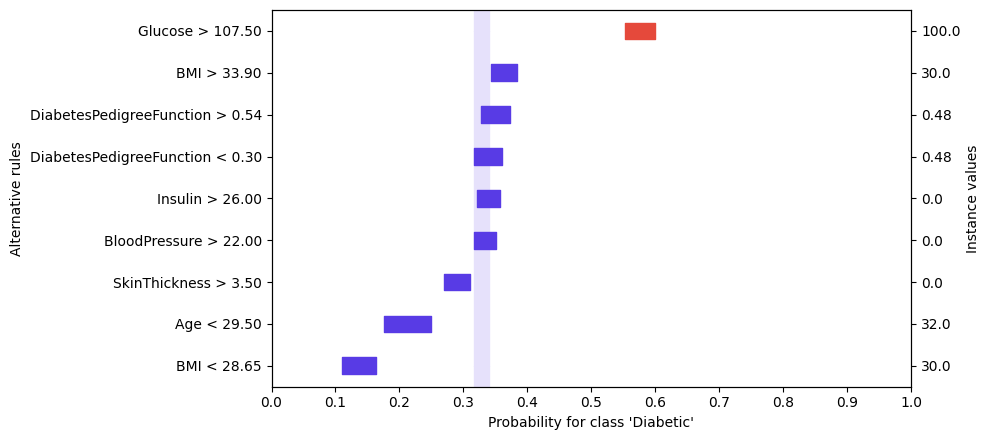

In [11]:
alternative_explanation = ce.explore_alternatives(x_test)
alternative_explanation.plot()

C:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


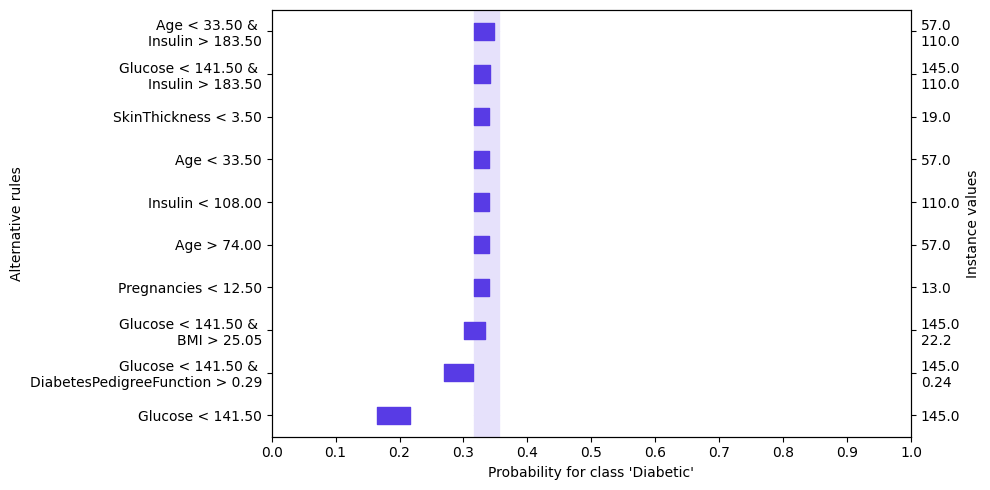

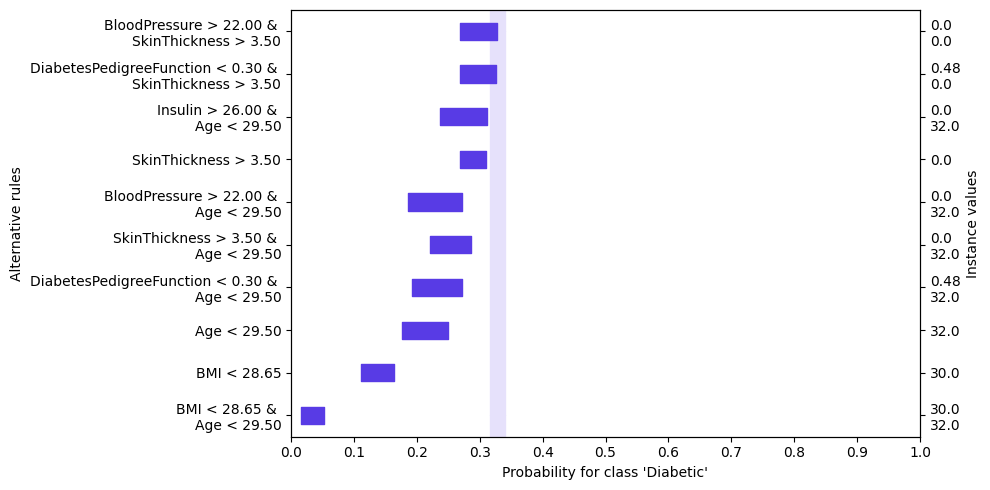

In [12]:
alternative_explanation.add_conjunctions().plot()

C:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


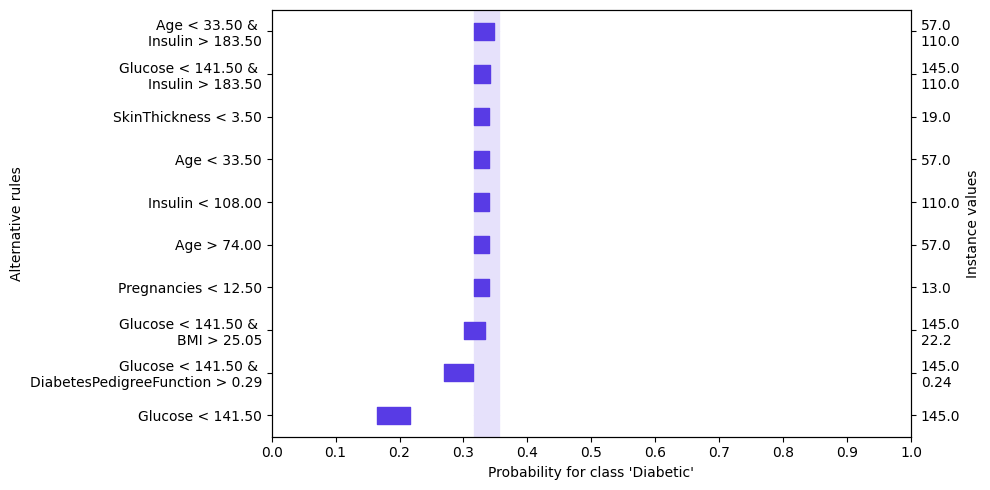

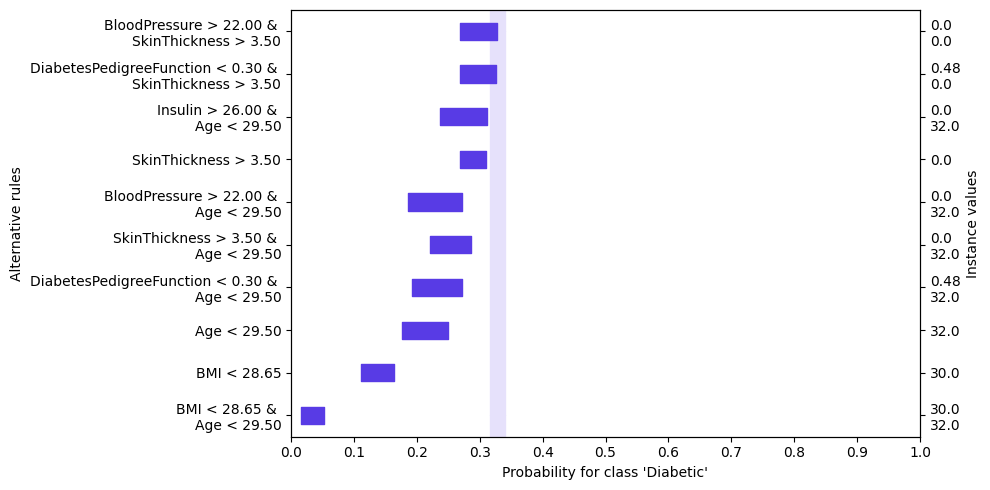

In [13]:
alternative_explanation.add_conjunctions().plot()

#### Conjunctional alternative explanations
As with regular and uncertainty explanations, conjunctions can also be used for alternative explanations.

As the `add_conjunctions` functions return the explanation object, they can be stacked.

C:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


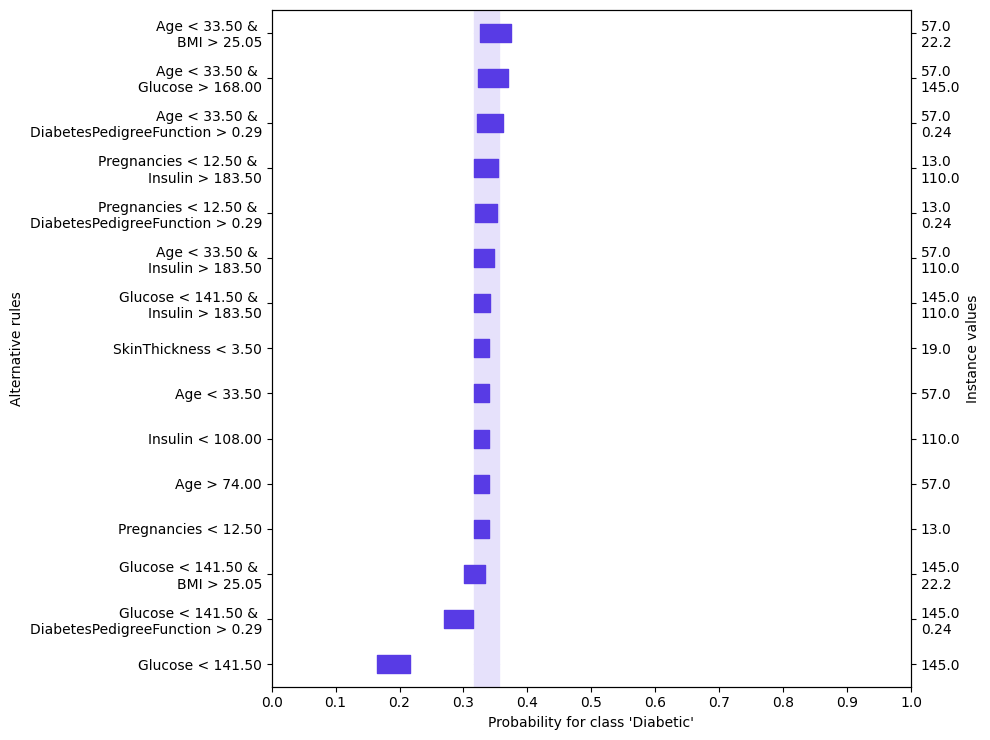

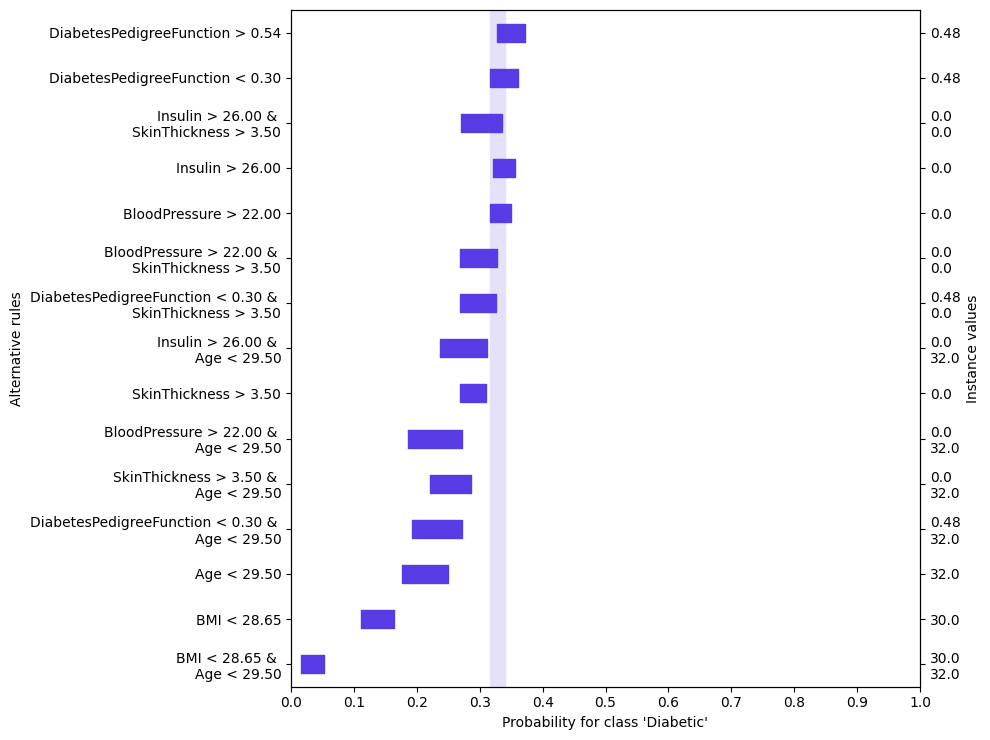

In [14]:
alternative_explanation.add_conjunctions().plot(filter_top=15)